# Proyecto 4: Machine Learning Explicable (XAI) - Ingesta y EDA

Este cuaderno se enfoca en la carga y exploración inicial del dataset **Boston Housing**, preparando el terreno para la aplicación de modelos y técnicas de explicabilidad (SHAP y LIME).

## 1. Carga de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de visualización
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Carga de Datos

In [2]:
data_path = "../data/BostonHousing.csv"
df = pd.read_csv(data_path)

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 3. Exploración Inicial (EDA)

### 3.1 Información General

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### 3.2 Estadísticas Descriptivas

In [4]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 3.3 Distribución de la Variable Objetivo (`medv`)

`medv` representa el valor medio de las viviendas ocupadas por sus propietarios en miles de dólares.

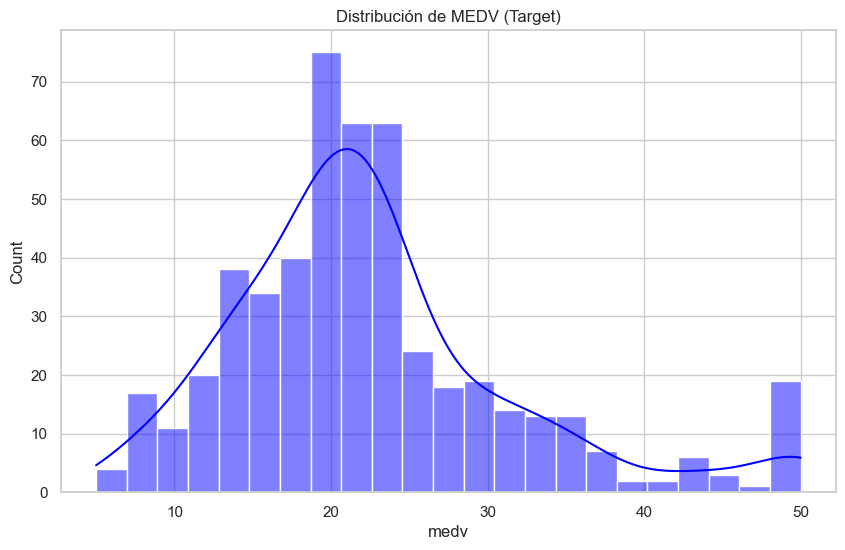

In [5]:
sns.histplot(df['medv'], kde=True, color='blue')
plt.title('Distribución de MEDV (Target)')
plt.show()

### 3.4 Análisis de Correlación

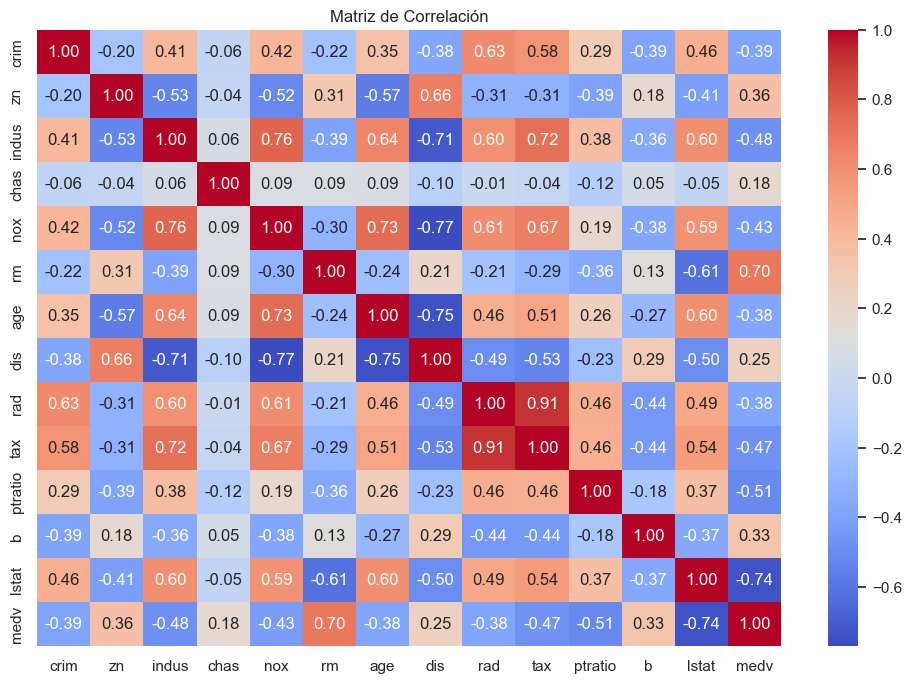

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

### 3.5 Relación entre Características y Target

Observamos las variables con mayor correlación con `medv`: `rm` (habitaciones) y `lstat` (% población de bajo estatus).

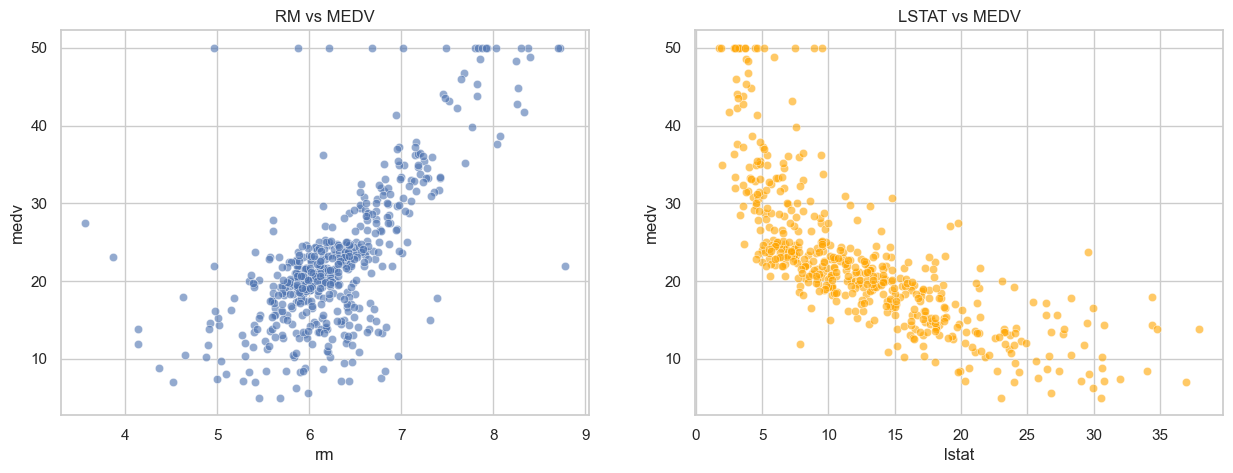

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=df, x='rm', y='medv', ax=axes[0], alpha=0.6)
axes[0].set_title('RM vs MEDV')

sns.scatterplot(data=df, x='lstat', y='medv', ax=axes[1], alpha=0.6, color='orange')
axes[1].set_title('LSTAT vs MEDV')

plt.show()

## 4. Conclusión del EDA

- No hay valores nulos evidentes.
- Las variables `rm` y `lstat` parecen ser las más influyentes.
- El dataset está listo para el modelado en el siguiente cuaderno.